In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
%matplotlib inline

In [83]:
df = sns.load_dataset('iris')

In [84]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [85]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [86]:
# change the value of the species 
#load label encoder

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [87]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [88]:
df['species'].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [89]:
# train test split
from sklearn.model_selection import train_test_split

In [90]:
x =  df.drop('species', axis=1)  # x is features and y is the target variable
y  = df['species']

In [91]:
x = x.values   # x.values is used to convert the DataFrame into a NumPy array, which is often required for machine learning models that expect input in array format. This allows for efficient numerical computations and compatibility with various machine learning libraries. 
y = y.values

In [92]:
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [93]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [94]:
import torch
X_train = torch.FloatTensor(X_train)  # is convert the array into tensor
X_test = torch.FloatTensor(X_test)

In [95]:
y_train = torch.LongTensor(y_train)  # is convert the array into tensor
y_test = torch.LongTensor(y_test)

In [96]:
# set the creation model to measure the error

model = Model(input_size=4, hidden_size=16, output_size=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # updates the model parameters to minimize the loss function.

In [97]:
epochs = 100
losses = []

for i in range(epochs):
    y_pred = model.forward(X_train)
    loss = criterion(y_pred, y_train)
    losses.append(loss.item())
    if i % 10 == 0:
        print(f'Epoch {i} Loss: {loss.item()}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0 Loss: 1.3947957754135132
Epoch 10 Loss: 0.8493480086326599
Epoch 20 Loss: 0.6071615815162659
Epoch 30 Loss: 0.465741902589798
Epoch 40 Loss: 0.3760780692100525
Epoch 50 Loss: 0.3066747486591339
Epoch 60 Loss: 0.24808740615844727
Epoch 70 Loss: 0.20102669298648834
Epoch 80 Loss: 0.16564100980758667
Epoch 90 Loss: 0.14008738100528717


Text(0, 0.5, 'Loss')

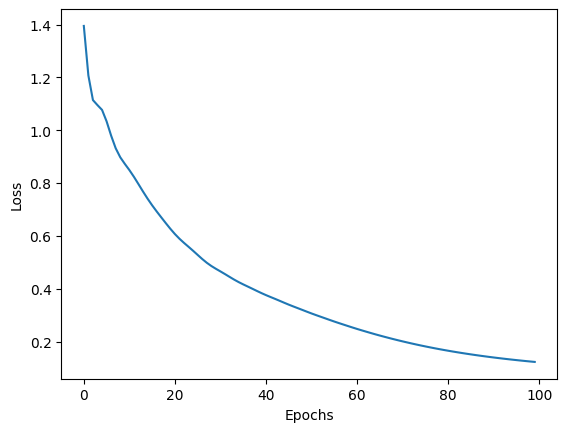

In [98]:
# Graph the loss over epochs
plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')

In [99]:
# evaluate model  on test data set 

with torch.no_grad(): # basically turn off back propagation
    y_eval = model.forward(X_test)  # X_test are the features of the test data set and y_eval is the predicted output of the model for the test data set.
    loss = criterion(y_eval, y_test)  # loss is the difference between the predicted output and the actual output of the test data set.
    



In [100]:
loss   

tensor(0.1298)

In [101]:
correct = 0
with torch.no_grad():
    for i , data in enumerate(X_test):
        y_eval = model.forward(data)


#  will tell us  what type of flower is predicted by the model for each test data point. The output will be in the form of a tensor, which can be converted to a NumPy array or a list for easier interpretation. The predicted class will correspond to the index of the highest value in the output tensor, which represents the model's confidence in each class.
        print(f'{i+1}.) {str(y_eval)}   \t {y_test[i]}')  # y_test[i] is the actual output of the test data set and y_eval is the predicted output of the model for the test data set.


      

1.) tensor([-1.2248,  3.7625,  2.0167])   	 1
2.) tensor([  8.1778,   3.8472, -10.8393])   	 0
3.) tensor([-6.8925,  3.9794, 10.1937])   	 2
4.) tensor([-1.4642,  3.6689,  2.3014])   	 1
5.) tensor([-1.3717,  4.0551,  2.2213])   	 1
6.) tensor([ 7.4517,  3.6613, -9.9079])   	 0
7.) tensor([ 0.4521,  3.5585, -0.3925])   	 1
8.) tensor([-3.4700,  3.8719,  5.1182])   	 2
9.) tensor([-2.3575,  3.6184,  3.6015])   	 1
10.) tensor([-0.1065,  3.6825,  0.3598])   	 1
11.) tensor([-2.9191,  3.7744,  4.3592])   	 2
12.) tensor([ 7.2144,  3.3906, -9.5333])   	 0
13.) tensor([  8.3931,   3.7882, -11.1680])   	 0
14.) tensor([ 7.2869,  3.4407, -9.6206])   	 0
15.) tensor([  8.1535,   3.4946, -10.7060])   	 0
16.) tensor([-1.2589,  3.8591,  2.0036])   	 1
17.) tensor([-4.9658,  3.5859,  7.3126])   	 2
18.) tensor([-0.3150,  3.5639,  0.6724])   	 1
19.) tensor([-1.3669,  3.5498,  2.1852])   	 1
20.) tensor([-4.9626,  3.5143,  7.2978])   	 2
21.) tensor([ 6.9208,  3.2960, -9.1015])   	 0
22.) tensor([

In [102]:
if y_eval.argmax().item() == y_test[i]:  # y_eval.argmax().item() is the predicted output of the model for the test data set and y_test[i] is the actual output of the test data set.
            correct += 1

print(f'we got {correct} correct')  # correct is the number of correct predictions made by the model on the test data set and len(X_test) is the total number of test data points. The accuracy is calculated as the ratio of correct predictions to total predictions, expressed as a percentage.

we got 1 correct


In [103]:
new_iris = torch.tensor([4.7 , 3.2, 1.3, 0.2])  # new_iris is a tensor that represents the features of a new iris flower. The values in the tensor correspond to the sepal length, sepal width, petal length, and petal width of the flower, respectively. This tensor can be used as input to the trained model to predict the species of the new iris flower based on its features.

In [104]:
with torch.no_grad():
    print(model.forward(new_iris)) 
    

tensor([ 7.4520,  3.3037, -9.8065])


In [105]:
newer_iris = torch.tensor([5.9 ,  3.0 , 5.1 , 1.8 ])

with torch.no_grad():
    print(model(newer_iris))

tensor([-3.1820,  3.4775,  4.7546])


In [106]:
# save and load model 

torch.save(model.state_dict() , 'my_model_iris.pt')

In [109]:
# Load and save the model 

new_model = Model(input_size=4, hidden_size=16, output_size=3)
new_model.load_state_dict(torch.load('my_model_iris.pt'))

<All keys matched successfully>

In [110]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)